# Limpiando los datos

In [230]:
import matplotlib.pyplot as plt
import pandas as pd

file_path = "online_retail.csv"

data = pd.read_csv(file_path)

data_cleaned = data.drop_duplicates()
data_cleaned = data_cleaned.dropna(subset=["CustomerID"])
#Valores duplicados antes de limpiarlos
print("Valores duplicados: ", data.duplicated().sum())
#Data limpiada
print("Valores duplicados de data limpiado: ", data_cleaned.duplicated().sum())
data_cleaned.head()

Valores duplicados:  5268
Valores duplicados de data limpiado:  0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Generando nuevas columnas y cambiando tipos de datos para una mejor lectura de la información

In [231]:
data_cleaned["TotalAmount"] = data_cleaned["Quantity"] * data_cleaned["UnitPrice"]
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [232]:
data_cleaned["InvoiceDate"] = pd.to_datetime(data_cleaned["InvoiceDate"])#Esto cambia el tipo de dato de "InvoiceDate" de object a datetime64 
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [233]:
data_cleaned.info()#Aqui se puede comprobar el cambio de tipo de dato

<class 'pandas.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  str           
 1   StockCode    401604 non-null  str           
 2   Description  401604 non-null  str           
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[us]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  str           
 8   TotalAmount  401604 non-null  float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(4)
memory usage: 30.6 MB


In [234]:
#Desglosando InvoiceDate en año, mes y hora
data_cleaned["Year"] = data_cleaned["InvoiceDate"].dt.year
data_cleaned["Month"] = data_cleaned["InvoiceDate"].dt.month
data_cleaned["Hour"] = data_cleaned["InvoiceDate"].dt.hour
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8


## Encontrando Insights en los datos

In [235]:
#Primero calcular las ventas por año
sales_by_year = data_cleaned.groupby("Year")["TotalAmount"].sum()
sales_by_year

Year
2010     552372.860
2011    7726146.564
Name: TotalAmount, dtype: float64

In [236]:
#Crear la columna semestre
data_cleaned["Semester"] = data_cleaned["Month"].apply(lambda x:1 if x<=6 else 2)
data_cleaned.head(1)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Hour,Semester
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.3,2010,12,8,2


In [237]:
#Obtener los datos de ventas por semestre
sales_by_semester = data_cleaned.groupby(["Year","Semester"])["TotalAmount"].sum()
sales_by_semester

Year  Semester
2010  2            552372.860
2011  1           3166939.041
      2           4559207.523
Name: TotalAmount, dtype: float64

## Encontrar las ventas trimestales y por mes

In [238]:
#Primero hay que crear la columna de trimestres

data_cleaned["Quarter"] = data_cleaned["Month"].apply(lambda x:1 if x<=3 else ( 2 if x<=6 else (3 if x<=9 else( 4 if x<=12 else -1))))#Nunca deberia devolver -1 porque los meses van del 1 al 12 si en algun punto lo devuelve habria un error

In [239]:
#Obtener Ventas Trimestrales
sales_by_quarter = data_cleaned.groupby(["Year","Quarter"])["TotalAmount"].sum()
sales_by_quarter

#Se puede observar que los dos ultimos trimestres hubo un incremento de casi 1 millon en ventas

Year  Quarter
2010  4           552372.860
2011  1          1487842.180
      2          1679096.861
      3          2117546.643
      4          2441660.880
Name: TotalAmount, dtype: float64

In [240]:
#Obtener Ventas Mes (Como ya tenemos la columna mes creada es más rapido calcular la suma de ventas por mes)
sales_by_month = data_cleaned.groupby(["Year","Month"])["TotalAmount"].sum()
sales_by_month

#En el mes 11 las ventas aumentaron muchisimo y bajaron en el mes 12

Year  Month
2010  12        552372.860
2011  1         473731.900
      2         435534.070
      3         578576.210
      4         425222.671
      5         647011.670
      6         606862.520
      7         573112.321
      8         615078.090
      9         929356.232
      10        973306.380
      11       1126815.070
      12        341539.430
Name: TotalAmount, dtype: float64

## Encontrando las devoluciones y las no devoluciones

In [241]:
total_returns = data_cleaned[data_cleaned["Quantity"] < 0].shape[0]
total_returns

8872

In [242]:
#Total no devoluciones
total_non_returns = data_cleaned[data_cleaned["Quantity"] >= 0].shape[0]
total_non_returns

392732

## Creando Gráficas para una Mejor Visualización de los Datos

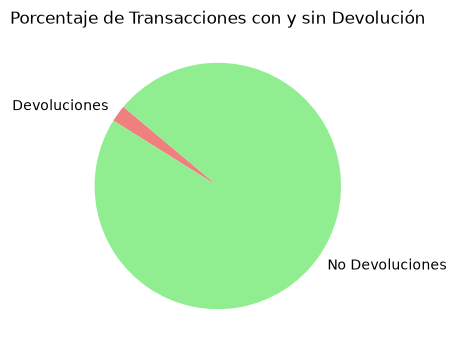

In [243]:
import matplotlib.pyplot as plt

labels = ["Devoluciones", "No Devoluciones"]
sizes = [total_returns, total_non_returns]
colors = ["lightcoral", "lightgreen"]

plt.figure(figsize = (4,4))
plt.pie(sizes, labels=labels, colors=colors, startangle=140)
plt.title("Porcentaje de Transacciones con y sin Devolución")
plt.show()

In [244]:
#Creando una nueva columna basada en el monto total de transacción (Ejemplo: "Low", "Medium", "High")
def categorize_total_amount(amount):
    if amount < 20:
        return "Low"
    elif 20 <= amount < 100:
        return "Medium"
    else:
        return "High"

data_cleaned["AmountCategory"] = data_cleaned["TotalAmount"].apply(categorize_total_amount)
data_cleaned.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount,Year,Month,Hour,Semester,Quarter,AmountCategory
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,8,2,4,Low
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8,2,4,Medium
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,8,2,4,Medium
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8,2,4,Medium
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8,2,4,Medium


In [245]:
#Creando Grafica de Pastel con las Categorias

#Primero encontrando el total de cada categoria
total_low_amount = data_cleaned[data_cleaned["AmountCategory"] == "Low"].shape[0]
total_low_amount


315319

In [246]:
total_medium_amount = data_cleaned[data_cleaned["AmountCategory"] == "Medium"].shape[0]
total_medium_amount

74616

In [247]:
total_high_amount = data_cleaned[data_cleaned["AmountCategory"] == "High"].shape[0]
total_high_amount

11669

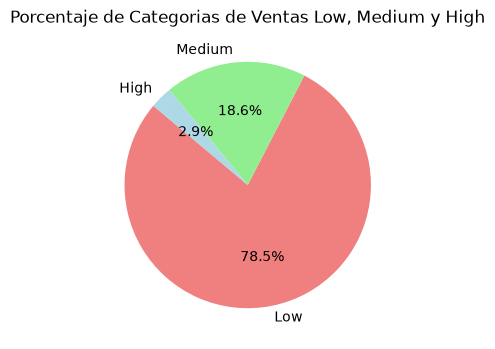

In [248]:
#Creando la grafica de pastel
#Ya no es necesario importar la libreria

labels = ["Low", "Medium", "High"]
sizes = [total_low_amount, total_medium_amount, total_high_amount]
colors = ["lightcoral", "lightgreen", "lightblue"]

plt.figure(figsize = (4,4))
plt.pie(sizes, labels=labels, colors=colors, startangle=140, autopct='%1.1f%%')
plt.title("Porcentaje de Categorias de Ventas Low, Medium y High")
plt.show()

## Distribución de Ventas por mes y año

Text(0, 0.5, 'Ventas Totales')

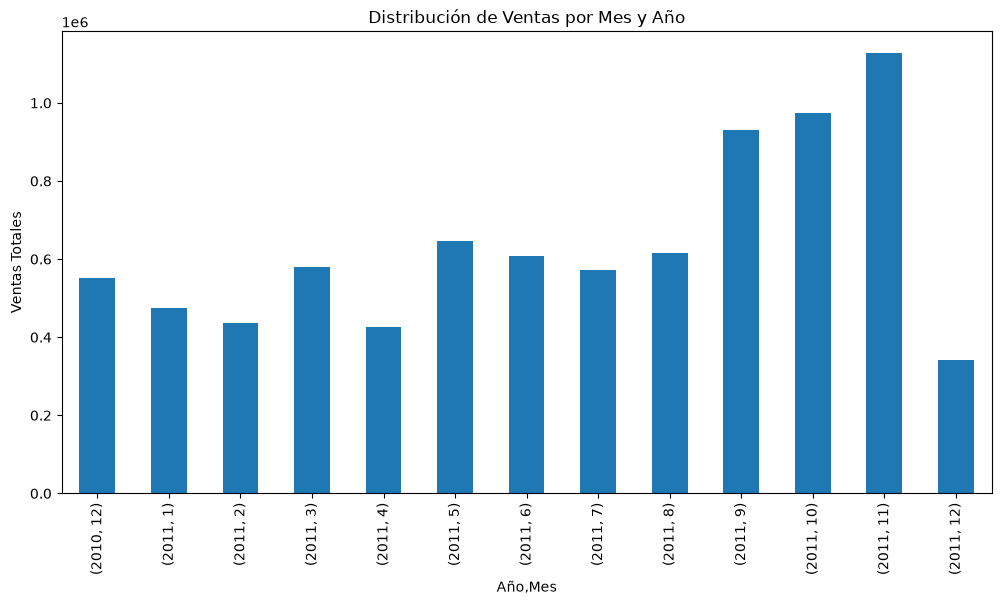

In [249]:
plt.figure(figsize=(12,6))
data_cleaned.groupby(["Year", "Month"])["TotalAmount"].sum().plot(kind="bar")
plt.title("Distribución de Ventas por Mes y Año")
plt.xlabel("Año,Mes")
plt.ylabel("Ventas Totales")

In [250]:
# Top 10 de productos más vendidos

top_products = data_cleaned.groupby("StockCode")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products = top_products.reset_index()
top_products = pd.merge(top_products, data_cleaned[["StockCode", "Description"]].drop_duplicates(), on="StockCode", how="left")
top_products

,StockCode,Quantity,Description
0,84077,53119,WORLD WAR 2 GLIDERS ASSTD DESIGNS
1,22197,48689,SMALL POPCORN HOLDER
2,22197,48689,POPCORN HOLDER
3,85099B,44963,JUMBO BAG RED RETROSPOT
4,84879,35215,ASSORTED COLOUR BIRD ORNAMENT
5,85123A,34185,WHITE HANGING HEART T-LIGHT HOLDER
6,85123A,34185,CREAM HANGING HEART T-LIGHT HOLDER
7,21212,33386,PACK OF 72 RETROSPOT CAKE CASES
8,23084,27045,RABBIT NIGHT LIGHT
9,22492,25880,MINI PAINT SET VINTAGE


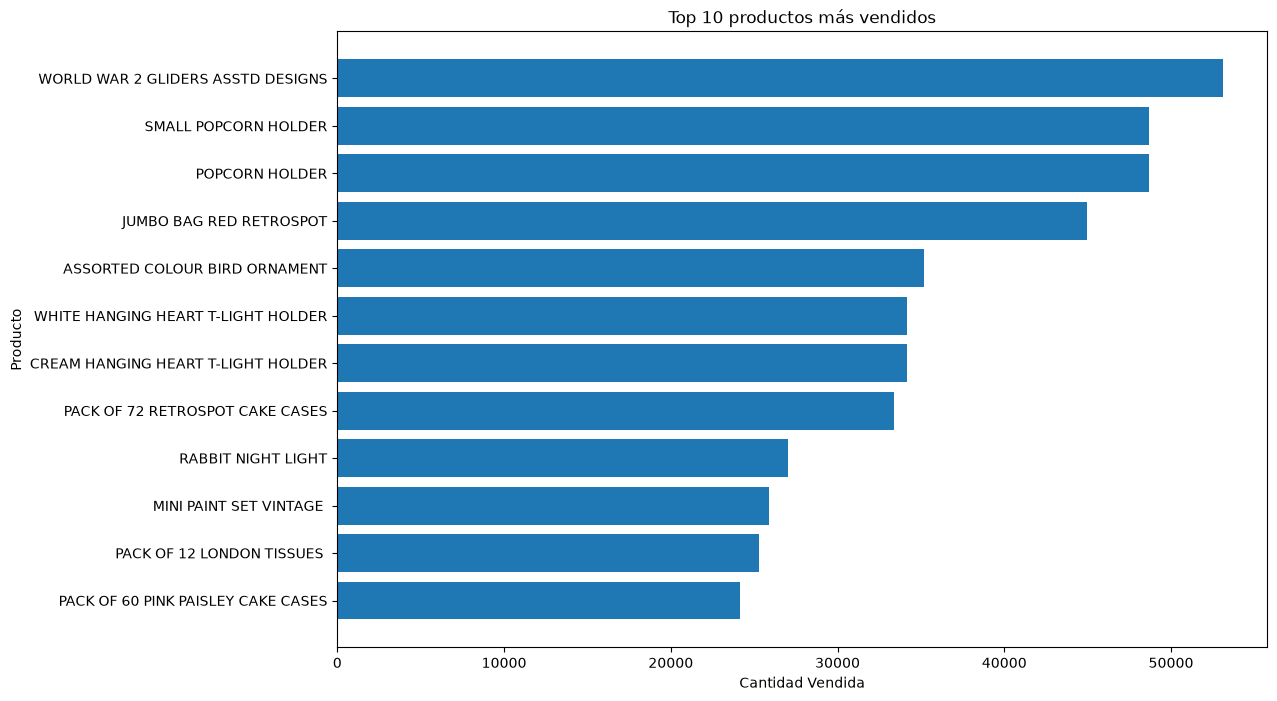

In [251]:
plt.figure(figsize=(12,8))
plt.barh(top_products["Description"], top_products["Quantity"])
plt.title("Top 10 productos más vendidos")
plt.xlabel("Cantidad Vendida")
plt.ylabel("Producto")
plt.gca().invert_yaxis()

plt.show()

## Cuales son los clientes más valiosos

In [252]:
#Top 10 de clientes más valiosos
# Top 10 clientes más valiosos
top_clients = (
    data_cleaned.groupby("CustomerID", as_index=False)
    .agg(TotalGastado=("TotalAmount", "sum"))
    .sort_values("TotalGastado", ascending=False)
    .head(10)
)

top_clients

,CustomerID,TotalGastado
1703,14646.0,279489.02
4233,18102.0,256438.49
3758,17450.0,187322.17
1895,14911.0,132458.73
55,12415.0,123725.45
1345,14156.0,113214.59
3801,17511.0,88125.38
3202,16684.0,65892.08
1005,13694.0,62690.54
2192,15311.0,59284.19


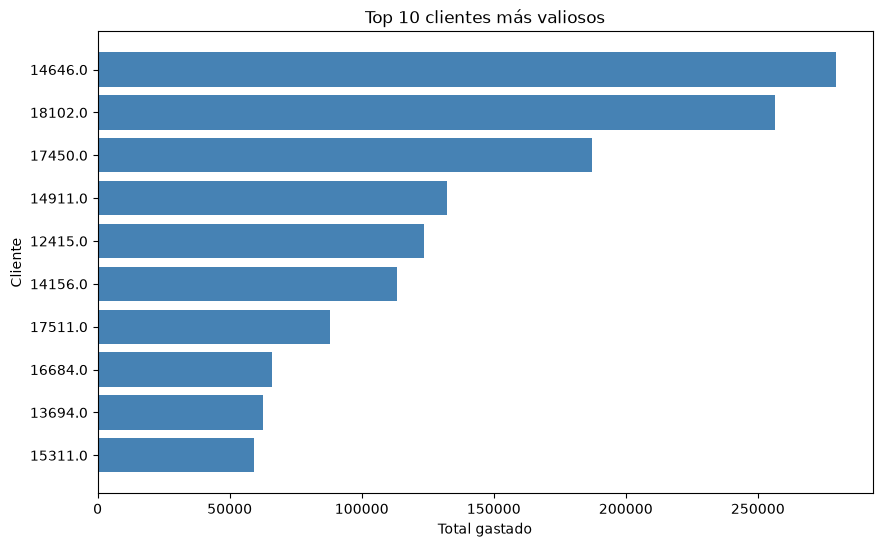

In [253]:
#Gráfica de los top 10 clientes
# Gráfico de Top 10 clientes
plt.figure(figsize=(10, 6))
plt.barh(top_clients["CustomerID"].astype(str), top_clients["TotalGastado"], color="steelblue")
plt.title("Top 10 clientes más valiosos")
plt.xlabel("Total gastado")
plt.ylabel("Cliente")
plt.gca().invert_yaxis()
plt.show()